# Test of the Reciever Simulator


In [98]:
from simulation.observation_handler import ObservationHandler
from simulation.loads import Load
from simulation.receiver import Receiver

import matplotlib.pyplot as plt
import numpy as np
import astropy.units as un

import os

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

In [99]:
test_receiver = Receiver(gamma_rec_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlockSDR0.s2p',
                         gains_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlock0.s2p')

test_receiver.change_freqs(np.linspace(60*un.MHz, 80*un.MHz, 512))

open_load = Load(physical_temperature=273,
                 label='open',
                 termination_type='open',
                 freqs=test_receiver.freqs)

short_load = Load(physical_temperature=273,
                 label='short',
                 termination_type='short',
                 freqs=test_receiver.freqs)

long_open = Load(physical_temperature=273,
                 label='long_open',
                 termination_type='open',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

long_short = Load(physical_temperature=273,
                 label='long_short',
                 termination_type='short',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

matched_ambient = Load(physical_temperature=273,
                       label='internal_load',
                       termination_type='matched',
                       freqs=test_receiver.freqs)

heated_load = Load(physical_temperature=matched_ambient.t_src+100,
                      label='heated_load',
                      termination_type='matched',
                      freqs=test_receiver.freqs)


observation_handler_obj = ObservationHandler(observation_length=1*3600*un.s,
                                             receiver=test_receiver,
                                             sources=[#long_open,
                                                      long_short,
                                                      open_load,
                                                      short_load],
                                            dicke_switch_sources=[matched_ambient,
                                                                  heated_load],
                                            dicke_switch_length=300*un.s,
                                            delta_t=1*un.s,
                                            n_t_unc_freq_coeffs=5,
                                            n_t_unc_time_coeffs=3,
                                            n_t_sin_freq_coeffs=3,
                                            n_t_sin_time_coeffs=4,
                                            n_t_cos_freq_coeffs=4,
                                            n_t_cos_time_coeffs=2)



Done


In [100]:
os.makedirs('simulated_data',
          exist_ok=True)

observation_handler_obj.save_to_hdf5(filepath="simulated_data/sim_data.hdf5")


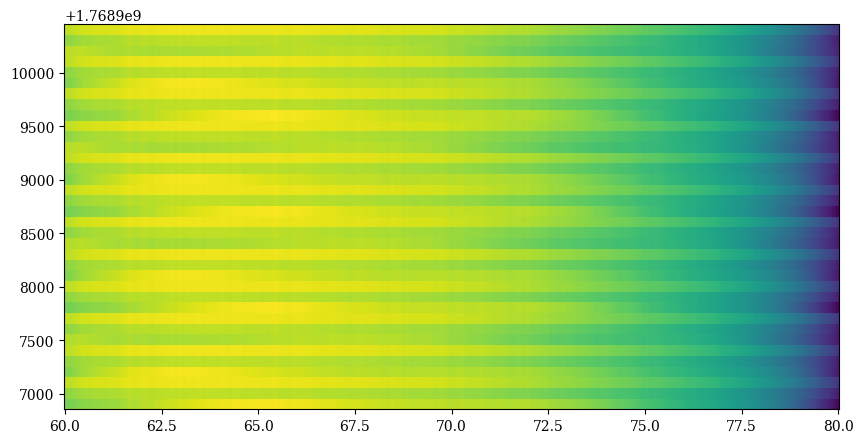

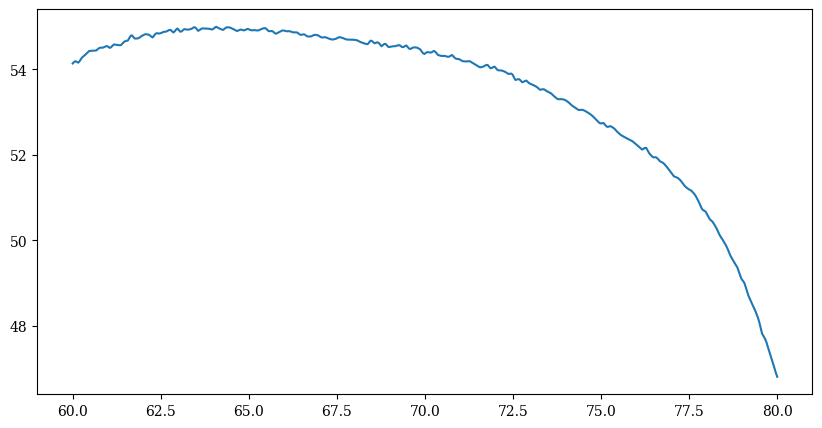

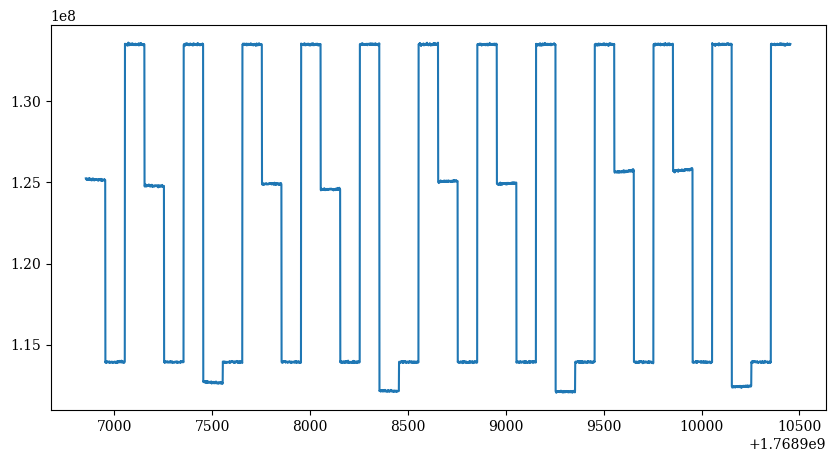

<class 'str'>
<class 'numpy.float64'>
internal_load
[272.75768033 273.01148434 273.04832487 ... 273.11989889 272.85991242
 273.07986701]
----
heated_load
[373.03340495 372.93924734 372.991564   ... 372.80099547 372.82530194
 372.90245224]
----
long_short
[272.96593834 273.16889895 273.02699661 ... 273.05534896 273.01582567
 273.04484828]
----
open
[273.15495836 272.76696676 272.96694429 ... 273.09698586 273.06201634
 273.1051996 ]
----
short
[273.00016535 273.09175241 273.16056384 ... 273.00061919 273.02697086
 272.96196675]
----


In [101]:

plt.pcolormesh(np.array(observation_handler_obj.freqs),
               np.array(observation_handler_obj.times),
               10*np.log10(observation_handler_obj.data))
plt.show()

plt.plot(observation_handler_obj.freqs,10*np.log10(np.mean(observation_handler_obj.data, axis=0)))
plt.show()

plt.plot(observation_handler_obj.times, observation_handler_obj.data.sum(axis=1))
plt.show()

print(type(observation_handler_obj.switch_states[0]))
print(type(observation_handler_obj.switch_times[0]))


for i, k in observation_handler_obj.temperature_dict.items():
    print(i)
    print(k)
    print('----')


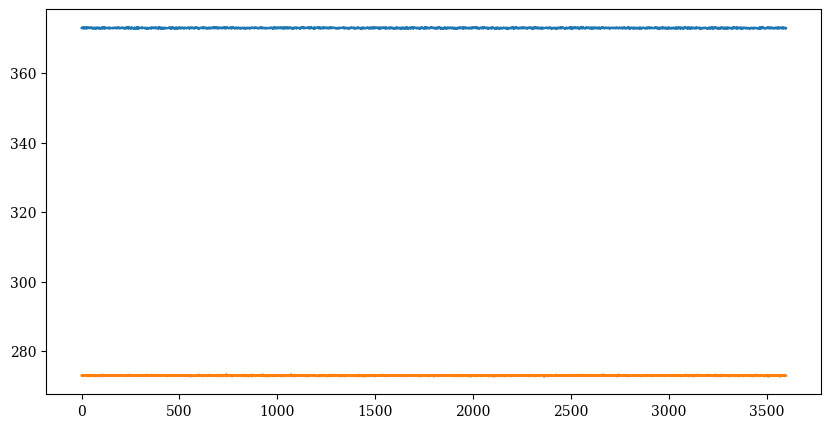

In [102]:
plt.plot(observation_handler_obj.temperature_dict['heated_load'])
plt.plot(observation_handler_obj.temperature_dict['short'])

In [103]:
from gcr.data_processing import create_nw_data_and_covariance_from_raw
from gcr.transfer_matrix_construction import construct_transfer_matrix


data_waterfall, covar_waterfall, final_times, final_states = create_nw_data_and_covariance_from_raw(waterfall=observation_handler_obj.data,
                                                                             times=observation_handler_obj.times,
                                                                             freqs=observation_handler_obj.freqs,
                                                                             switch_times=observation_handler_obj.switch_times,
                                                                             switch_states=observation_handler_obj.switch_states,
                                                                             source_temperatures=observation_handler_obj.temperature_dict,
                                                                             gamma_src_dict=observation_handler_obj.gamma_src_dict,
                                                                             noise_wave_loads=['open',
                                                                                               'short',
                                                                                               'long_open',
                                                                                               'long_short'],
                                                                            internal_load_label='internal_load',
                                                                            noise_source_label='heated_load',
                                                                            switch_buffer=2*un.s,
                                                                            gamma_rec=observation_handler_obj.gamma_rec)


In [104]:
print(final_states)

[np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_short'), np.str_('open'), np.str_('short')]


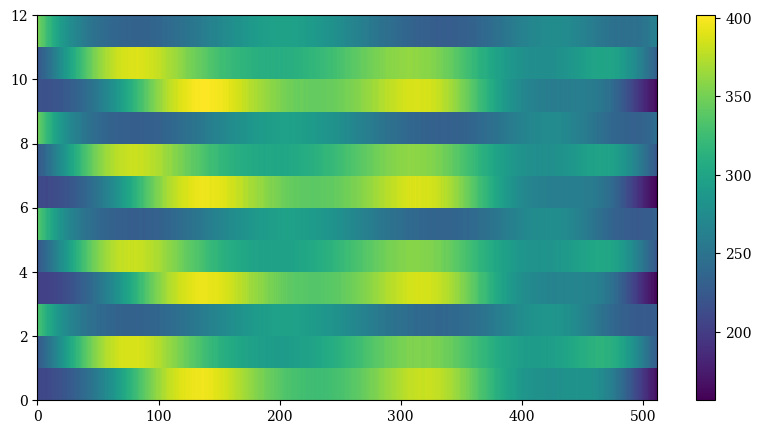

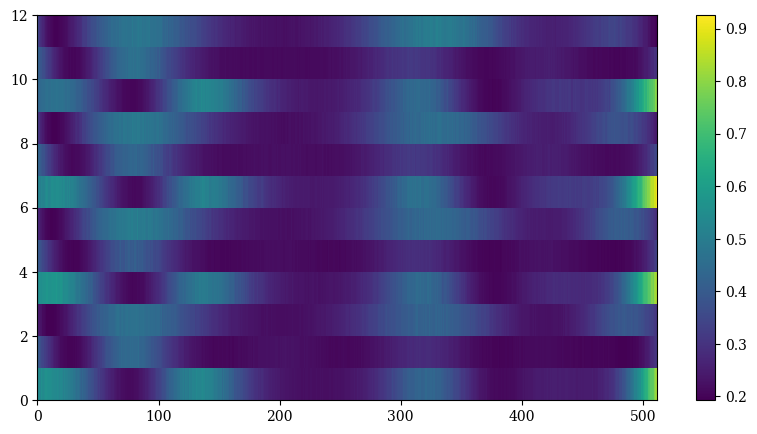

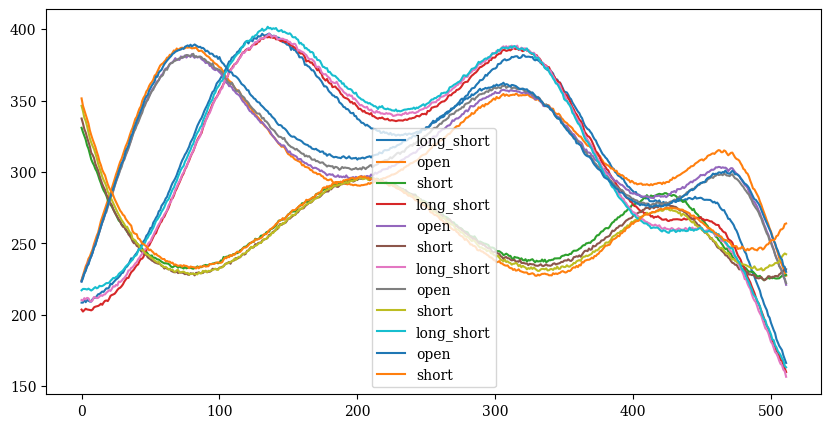

In [105]:
plt.pcolormesh(data_waterfall)
plt.colorbar()
plt.show()

plt.pcolormesh(covar_waterfall)
plt.colorbar()
plt.show()

for l, state in zip(data_waterfall, final_states):
    plt.plot(l, label=state)
plt.legend()
plt.show()



In [106]:
print(type(final_times[0]))

example_time = 100 *un.day

float_time = float(example_time.to(un.s) / un.s)

print(float_time)

<class 'float'>
8640000.0


In [129]:
unc_coeffs_deg = (5,5)
cos_coeffs_deg = (5,5)
sin_coeffs_deg = (5,5)

transfer_matrix, (freq_norm, time_norm) = construct_transfer_matrix(np.array(observation_handler_obj.freqs),
                                            np.array(final_times),
                                            switch_states_array=final_states,
                                            unc_poly_orders=unc_coeffs_deg,
                                            cos_poly_orders=cos_coeffs_deg,
                                            sin_poly_orders=sin_coeffs_deg,
                                            switch_state_src_gamma_dict=observation_handler_obj.gamma_src_dict,
                                            gamma_rec=observation_handler_obj.gamma_rec,
                                            return_norm_funcs=True)

print(freq_norm)

<function array_normalisation.<locals>.array_norm_func at 0x31752d3a0>


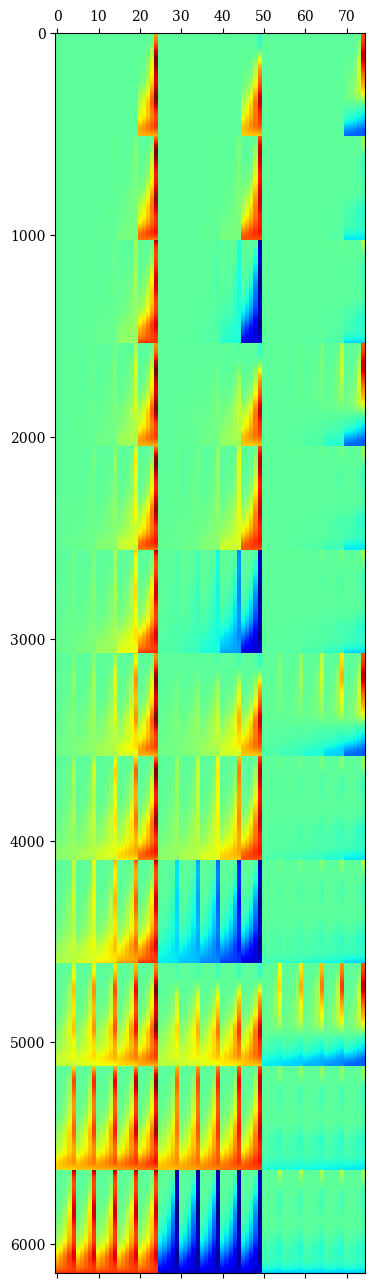

In [130]:
plt.matshow(transfer_matrix, aspect='auto', cmap='jet')
plt.show()

(6144,)
(6144, 75)
[ 3.48384373e+02 -4.25878129e+02 -2.17827948e+02  3.52232632e+02
 -5.42485309e+01 -6.47731539e+02  8.18037987e+02  4.28335309e+02
 -6.91495252e+02  9.60573388e+01 -1.13529710e+03  2.95516001e+03
 -2.70439237e+03  9.72120127e+02 -5.14821930e+01  2.87521579e+03
 -5.90423464e+03  3.84090983e+03 -8.43271791e+02  1.47397715e+01
 -8.83241183e+02  1.68679599e+03 -1.00167269e+03  1.90494358e+02
  2.96714354e+02  6.35994453e+02 -6.29080189e+02 -2.98143551e+02
  4.52296722e+02 -1.29159879e+02 -1.29170481e+03  1.26215351e+03
  6.06959493e+02 -9.15722438e+02  2.71891670e+02  8.62022194e+02
 -8.24251891e+02 -4.10893047e+02  6.10934037e+02 -1.91564054e+02
 -2.22619545e+02  2.74943276e+02 -9.86853488e+01 -1.89062019e+01
  3.87781613e+01  2.09171980e+01 -4.32820501e+01  7.95393534e+01
 -4.34977042e+01  1.84087189e+01 -8.90880530e+02  1.77603500e+03
 -1.03708242e+03  1.35836100e+02  1.03535893e+00  1.84994385e+03
 -3.68416562e+03  1.43977927e+03  5.16179232e+02 -1.40027988e+02
 -1.11

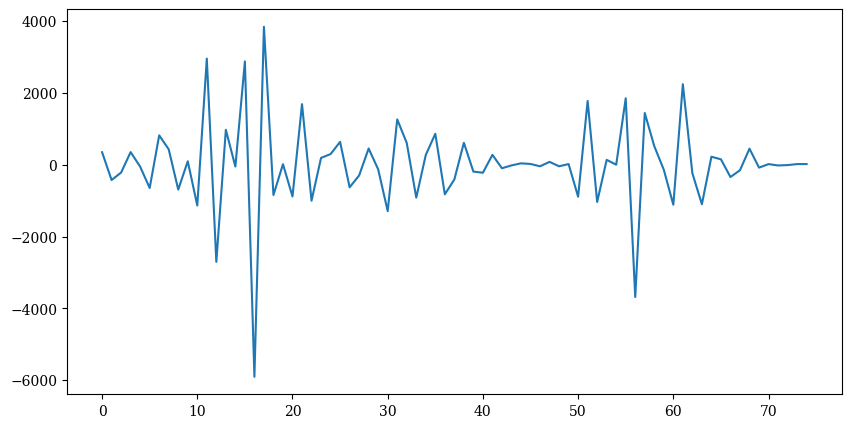

In [131]:
flattened_data = data_waterfall.flatten()

print(flattened_data.shape)
print(transfer_matrix.shape)

t_vec = np.linalg.lstsq(transfer_matrix, flattened_data)[0]


plt.plot(t_vec)


print(t_vec)

In [132]:
from gcr.basis_construction import reconstruct_surface

In [133]:
n_t_unc_coeffs = unc_coeffs_deg[0]*unc_coeffs_deg[-1]
n_t_cos_coeffs = cos_coeffs_deg[0]*cos_coeffs_deg[-1]
n_t_sin_coeffs = sin_coeffs_deg[0]*sin_coeffs_deg[-1]


t_unc_coeffs = t_vec[:n_t_unc_coeffs]
t_cos_coeffs = t_vec[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = t_vec[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)

[  348.38437276  -425.87812923  -217.82794766   352.2326322
   -54.24853094  -647.73153923   818.03798712   428.3353086
  -691.49525238    96.0573388  -1135.29709564  2955.16000842
 -2704.39237151   972.12012678   -51.48219295  2875.2157947
 -5904.2346424   3840.90982599  -843.27179056    14.73977147
  -883.24118302  1686.79598779 -1001.67269298   190.49435834
   296.71435413]
[  635.99445284  -629.08018893  -298.1435506    452.29672186
  -129.15987869 -1291.70480546  1262.15351334   606.95949259
  -915.72243759   271.89167013   862.02219379  -824.25189091
  -410.89304703   610.93403653  -191.56405399  -222.61954547
   274.94327602   -98.68534878   -18.90620192    38.77816134
    20.91719796   -43.28205014    79.5393534    -43.49770421
    18.40871888]
[-8.90880530e+02  1.77603500e+03 -1.03708242e+03  1.35836100e+02
  1.03535893e+00  1.84994385e+03 -3.68416562e+03  1.43977927e+03
  5.16179232e+02 -1.40027988e+02 -1.11379444e+03  2.24189638e+03
 -2.37646434e+02 -1.10047921e+03  2.231055

In [134]:

t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


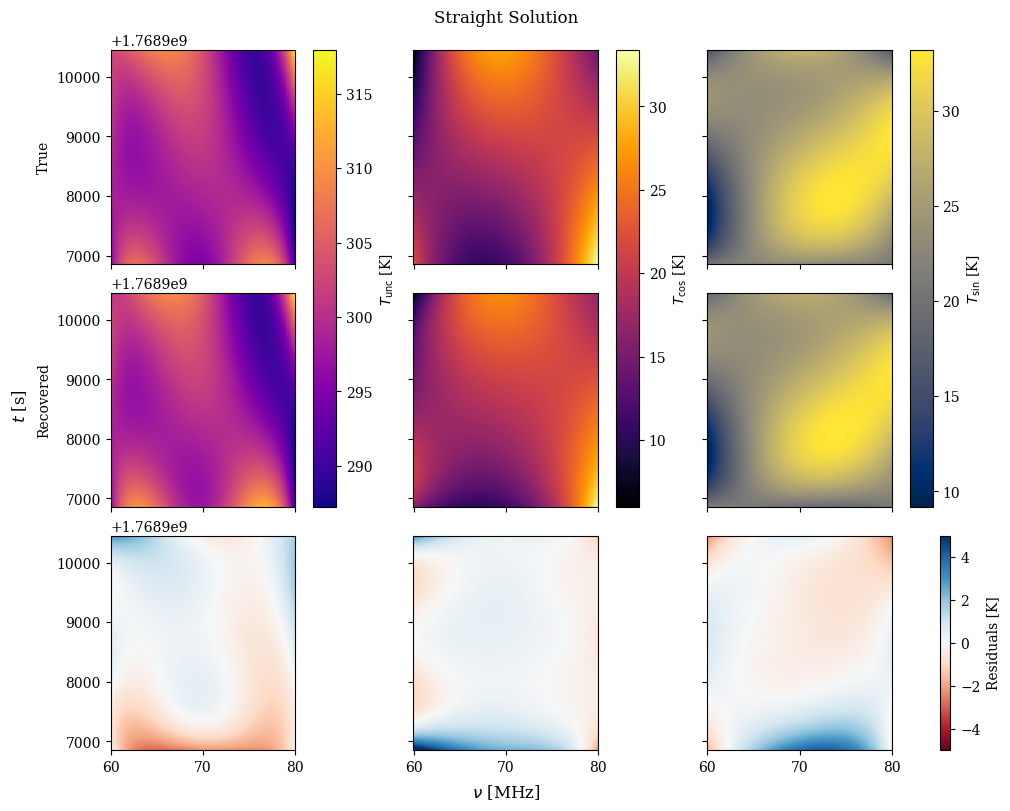

In [ ]:
# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)


unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-5,
                     vmax=5,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-5,
                     vmax=5,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-5,
                     vmax=5,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Straight Solution')
plt.show()


In [161]:
flat_cov = covar_waterfall.flatten()
inv_cov = 1 / flat_cov

from gcr.noise_wave_gcr import construct_gcr_lhs, construct_gcr_rhs
from scipy.sparse.linalg import cg


S_cov = np.abs(t_vec) / 5
S_inv =  1/S_cov #np.zeros_like(t_vec)# 1/S_cov

print(S_inv)

lhs = construct_gcr_lhs(transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv)

rhs = construct_gcr_rhs(d=flattened_data,
                        H_matrix=transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv,
                        T_nw0=t_vec,
                        omega_d=np.zeros_like(flattened_data),
                        omega_t=np.zeros_like(t_vec))

gcr_wsol = cg(lhs, rhs, x0=t_vec)[0]



[1.43519641e-02 1.17404479e-02 2.29538957e-02 1.41951641e-02
 9.21683945e-02 7.71924740e-03 6.11218559e-03 1.16730979e-02
 7.23070763e-03 5.20522436e-02 4.40413353e-03 1.69195576e-03
 1.84884414e-03 5.14339726e-03 9.71209600e-02 1.73899991e-03
 8.46849813e-04 1.30177490e-03 5.92928645e-03 3.39218285e-01
 5.66096792e-03 2.96419960e-03 4.99165050e-03 2.62474965e-02
 1.68512238e-02 7.86170379e-03 7.94811232e-03 1.67704449e-02
 1.10546899e-02 3.87117118e-02 3.87085345e-03 3.96148325e-03
 8.23778203e-03 5.46016980e-03 1.83896770e-02 5.80031470e-03
 6.06610680e-03 1.21686167e-02 8.18418962e-03 2.61009302e-02
 2.24598428e-02 1.81855693e-02 5.06660823e-02 2.64463482e-01
 1.28938553e-01 2.39037753e-01 1.15521330e-01 6.28619644e-02
 1.14948595e-01 2.71610427e-01 5.61242482e-03 2.81525983e-03
 4.82121760e-03 3.68090661e-02 4.82924314e+00 2.70278474e-03
 1.35715940e-03 3.47275453e-03 9.68655786e-03 3.57071474e-02
 4.48915871e-03 2.23025472e-03 2.10396593e-02 4.54347519e-03
 2.24109214e-02 3.324083

[  348.38437276  -425.87812923  -217.82794766   352.2326322
   -54.24853094  -647.73153923   818.03798712   428.3353086
  -691.49525238    96.0573388  -1135.29709564  2955.16000842
 -2704.39237151   972.12012678   -51.48219295  2875.2157947
 -5904.2346424   3840.90982599  -843.27179056    14.73977147
  -883.24118302  1686.79598779 -1001.67269298   190.49435834
   296.71435413]
[  635.99445284  -629.08018893  -298.1435506    452.29672186
  -129.15987869 -1291.70480546  1262.15351334   606.95949259
  -915.72243759   271.89167013   862.02219379  -824.25189091
  -410.89304703   610.93403653  -191.56405399  -222.61954547
   274.94327602   -98.68534878   -18.90620192    38.77816134
    20.91719796   -43.28205014    79.5393534    -43.49770421
    18.40871888]
[-8.90880530e+02  1.77603500e+03 -1.03708242e+03  1.35836100e+02
  1.03535893e+00  1.84994385e+03 -3.68416562e+03  1.43977927e+03
  5.16179232e+02 -1.40027988e+02 -1.11379444e+03  2.24189638e+03
 -2.37646434e+02 -1.10047921e+03  2.231055

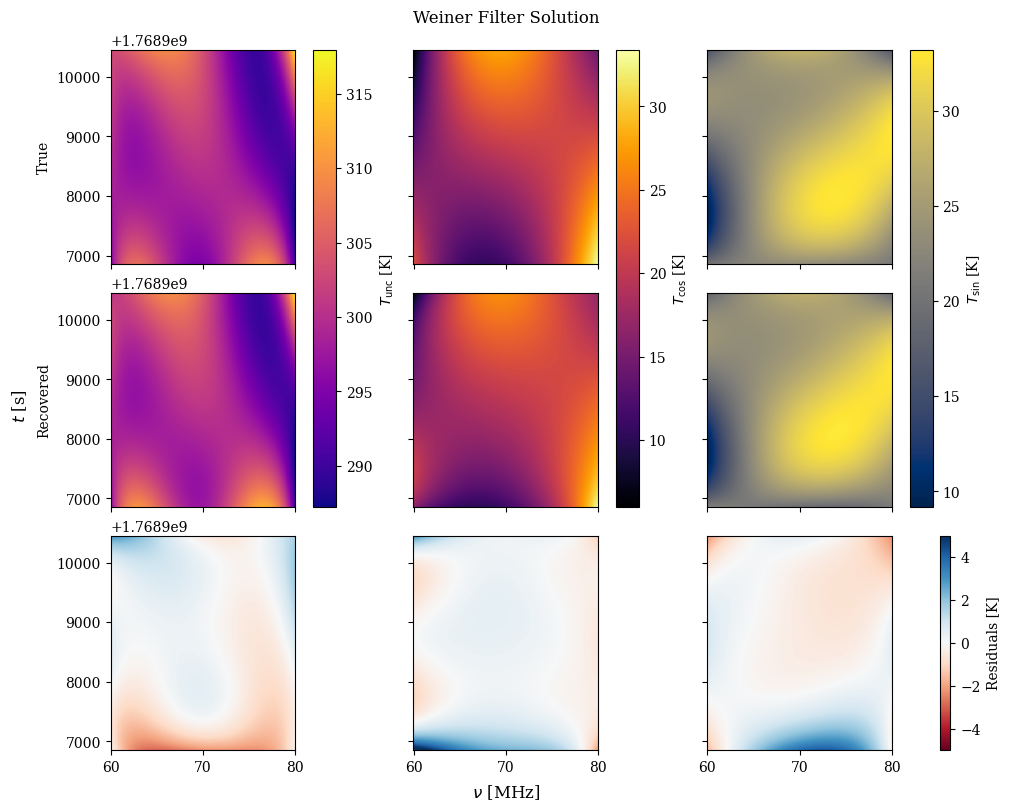

In [162]:
t_unc_coeffs = gcr_wsol[:n_t_unc_coeffs]
t_cos_coeffs = gcr_wsol[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = gcr_wsol[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)


t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)


unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-5,
                     vmax=5,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-5,
                     vmax=5,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-5,
                     vmax=5,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Weiner Filter Solution')
plt.show()
